# **Brain MRI Tumour Segmentation and Subregion Analysis**

### Problem Statement:

#### The project aims to develop a robust image analysis pipeline for segmenting and characterizing gliomas using multi-sequence brain MRI, including T1, T2, FLAIR, and post-contrast T1 scans. The goal is to identify clinically relevant tumour subregions—enhancing tumour, tumour core, and peritumoral oedema—and extract features such as intensity statistics, shape descriptors, and texture measures. These features can be used to assess tumour heterogeneity and potentially classify gliomas into high- and low-grade categories. Public datasets like BraTS will be used for validation and benchmarking.

##### Team Members: Indira H S, Shaivi R Panchal, Reva Laghate, Sneha Sarkar, Tejasvee Singh

Image shape (X, Y, Z): (240, 240, 155)


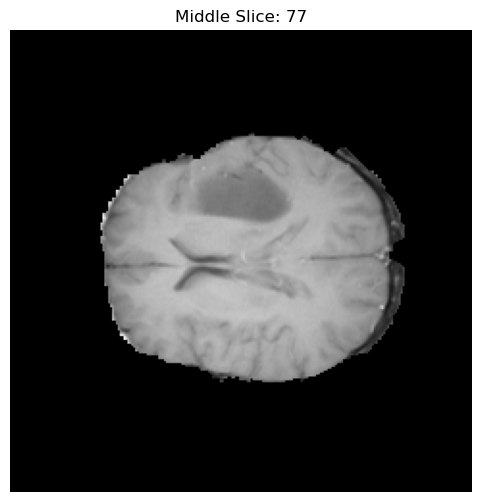

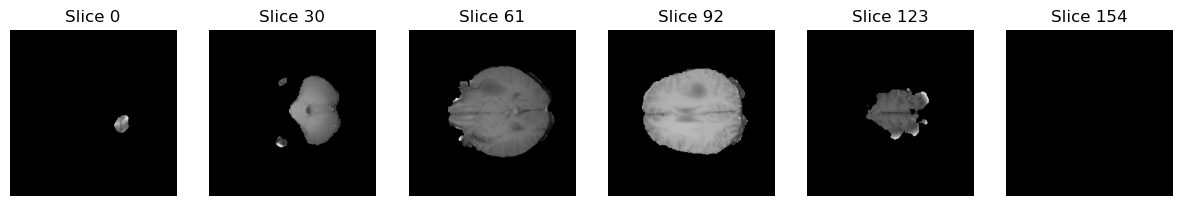

In [1]:
# === Import required libraries ===
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# === Load NIfTI file ===
nifti_file = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz" 
img = nib.load(nifti_file)
data = img.get_fdata()  # Convert image to NumPy array
print("Image shape (X, Y, Z):", data.shape)

# === Visualize middle slice ===
middle_slice = data.shape[2] // 2
plt.figure(figsize=(6,6))
plt.imshow(data[:, :, middle_slice], cmap='gray')
plt.title(f'Middle Slice: {middle_slice}')
plt.axis('off')
plt.show()

# === Visualize multiple slices evenly spaced ===
num_slices = 6
slice_indices = np.linspace(0, data.shape[2]-1, num_slices, dtype=int)

fig, axes = plt.subplots(1, num_slices, figsize=(15, 5))
for i, idx in enumerate(slice_indices):
    axes[i].imshow(data[:, :, idx], cmap='gray')
    axes[i].set_title(f'Slice {idx}')
    axes[i].axis('off')
plt.show()

##### The above code:
##### 1. Loads the MRI volume into a NumPy array.
##### 2. Displays the middle slice for a quick check.
##### 3. Displays multiple slices evenly spaced to inspect the full dataset.

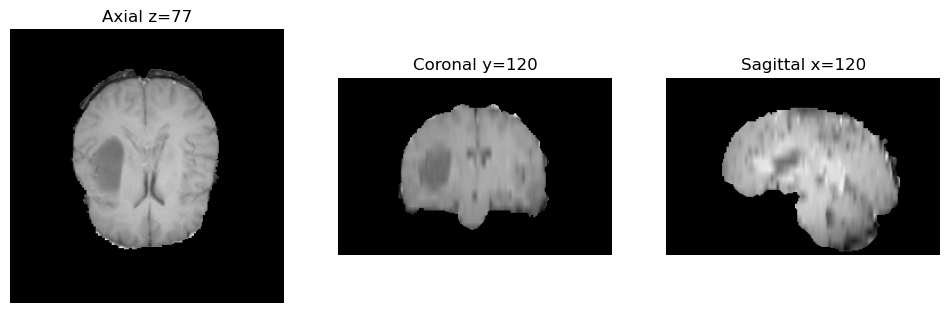

In [9]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# load
img = nib.load(r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz")
data = img.get_fdata()        # shape (X, Y, Z)
affine = img.affine           # voxel -> world mapping

# pick slice indices (center)
x, y, z = np.array(data.shape) // 2

# axial (Z): show as data[:, :, z]
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(np.rot90(data[:, :, z]), cmap='gray')
plt.title(f'Axial z={z}')
plt.axis('off')

# coronal (Y): data[:, y, :]
plt.subplot(1,3,2)
plt.imshow(np.rot90(data[:, y, :]), cmap='gray')
plt.title(f'Coronal y={y}')
plt.axis('off')

# sagittal (X): data[x, :, :]
plt.subplot(1,3,3)
plt.imshow(np.rot90(data[x, :, :]), cmap='gray')
plt.title(f'Sagittal x={x}')
plt.axis('off')

plt.show()

##### The above code:
##### 1. Loads a 3D MRI scan.
##### 2. Picks the central slices along X, Y, and Z axes.
##### 3. Displays axial (top-down), coronal (front-back), and sagittal (side) views in one figure.
##### 4.Rotates slices for correct orientation so the brain looks natural.

=== NIfTI Metadata ===
Filename: D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz
Image shape (X,Y,Z[,T]): (240, 240, 155)
Voxel dimensions (mm): (1.0, 1.0, 1.0)
Data type: int16
Description:                                                                                 
Intent name/code: b'', 0
Number of dimensions: [  3 240 240 155   1   1   1   1]
Affine transformation matrix (voxel -> world coordinates):
[[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

=== Full Header Fields ===
sizeof_hdr: 348
data_type: b''
db_name: b''
extents: 0
session_error: 0
regular: b'r'
dim_info: 0
dim: [  3 240 240 155   1   1   1   1]
intent_p1: 0.0
intent_p2: 0.0
intent_p3: 0.0
intent_code: 0
datatype: 4
bitpix: 16
slice_start: 0
pixdim: [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset: 0.0
scl_slope: nan
scl_inter: nan
slice_end: 0
slice_code: 0
xyzt_units: 2
cal_max: 0.0
cal_min: 0.0
slice_duration: 0.0
toffset

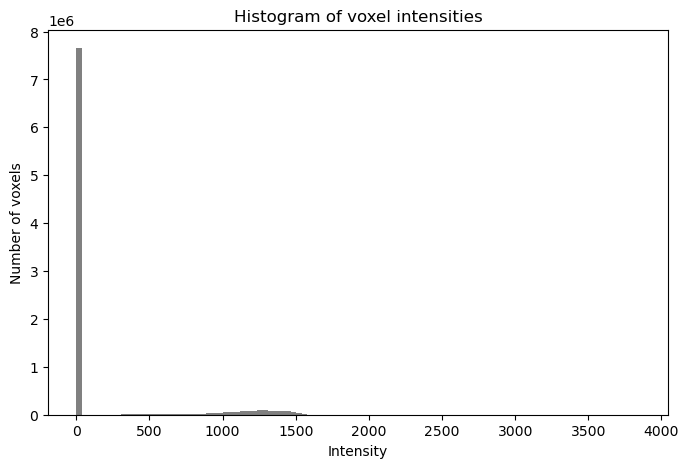

In [9]:
import nibabel as nib

# === Load NIfTI file ===
nifti_file = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz"
img = nib.load(nifti_file)

# === Header and basic info ===
hdr = img.header

print("=== NIfTI Metadata ===")
print(f"Filename: {nifti_file}")
print(f"Image shape (X,Y,Z[,T]): {img.shape}")
print(f"Voxel dimensions (mm): {hdr.get_zooms()}")
print(f"Data type: {hdr.get_data_dtype()}")
print(f"Description: {hdr['descrip'].tobytes().decode('utf-8').strip()}")
print(f"Intent name/code: {hdr.get('intent_name', '')}, {hdr.get('intent_code', '')}")
print(f"Number of dimensions: {hdr['dim']}")
print(f"Affine transformation matrix (voxel -> world coordinates):\n{img.affine}")

# Optional: print all header fields
print("\n=== Full Header Fields ===")
for key in hdr:
    print(f"{key}: {hdr[key]}")

print("\n=== Inspection of Intensity Ranges ===")
print("Intensity range:", data.min(), "-", data.max())
print("Mean intensity:", data.mean())
print("Standard deviation:", data.std())


plt.figure(figsize=(8,5))
plt.hist(data.flatten(), bins=100, color='gray')
plt.title("Histogram of voxel intensities")
plt.xlabel("Intensity")
plt.ylabel("Number of voxels")
plt.show()



##### The above code:
##### 1. Loads the image and header.
##### 2. Prints basic metadata (shape, voxel size, data type, description).
##### 3. Shows the full header fields for inspection.
##### 4. Checks intensity range and statistics.
##### 5. Plots a histogram to visualize voxel intensity distribution.

In [4]:
! pip install nibabel

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ------------ --------------------------- 1.0/3.3 MB 8.6 MB/s eta 0:00:01
   ----------------------------------- ---- 2.9/3.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 8.7 MB/s eta 0:00:00


In [8]:
import nibabel as nib
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation

# Load image
img = nib.load(r"C:\Users\Aryan\Downloads\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii\TCGA-CS-4942_1997.02.22_t1.nii")
data = img.get_fdata()
affine = img.affine

# Compute transform from current orientation to RAS
current_ornt = io_orientation(affine)
ras_ornt = axcodes2ornt(('R','A','S'))
transform = ornt_transform(current_ornt, ras_ornt)

# Apply the reorientation
data_ras = apply_orientation(data, transform)
affine_ras = nib.orientations.inv_ornt_aff(transform, data.shape) @ affine

# Save reoriented image
nib.save(nib.Nifti1Image(data_ras, affine_ras), 'image_RAS.nii')

# Verify
from nibabel.orientations import aff2axcodes
print(aff2axcodes(nib.load('image_RAS.nii').affine))  # should print ('R','A','S')


('R', 'A', 'S')


In [10]:
! pip install simpleitk

   ---------------------------------------- 0.0/18.8 MB ? eta -:--:--
   -- ------------------------------------- 1.3/18.8 MB 8.8 MB/s eta 0:00:02
   ------ --------------------------------- 3.1/18.8 MB 8.6 MB/s eta 0:00:02
   ---------- ----------------------------- 5.0/18.8 MB 8.7 MB/s eta 0:00:02
   --------------- ------------------------ 7.1/18.8 MB 9.0 MB/s eta 0:00:02
   ----------------- ---------------------- 8.4/18.8 MB 8.7 MB/s eta 0:00:02
   ---------------------- ----------------- 10.7/18.8 MB 8.9 MB/s eta 0:00:01
   -------------------------- ------------- 12.6/18.8 MB 8.8 MB/s eta 0:00:01
   ------------------------------ --------- 14.4/18.8 MB 8.8 MB/s eta 0:00:01
   ---------------------------------- ----- 16.3/18.8 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------  18.4/18.8 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 18.8/18.8 MB 8.8 MB/s eta 0:00:00


In [16]:
import nibabel as nib
from scipy.ndimage import zoom
import numpy as np

# Load image
img = nib.load(r"C:\Users\Aryan\Downloads\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii\TCGA-CS-4942_1997.02.22_t1.nii")
data = img.get_fdata()
affine = img.affine

# Original shape
print("Original shape:", data.shape)

# Original voxel spacing from affine
spacing = np.sqrt((affine[:3, :3]**2).sum(0))
print("Original spacing (mm):", spacing)

Original shape: (240, 240, 155)
Original spacing (mm): [1. 1. 1.]
